In [57]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from matplotlib.ticker import PercentFormatter

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [88]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title'] == 'Data Scientist')].copy()

In [89]:
df_DA_US['job_posted_month_no']= df_DA_US['job_posted_date'].dt.month
df_DA_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
111,Data Scientist,Data Scientist,"Atlanta, GA",via ZipRecruiter,Full-time,False,"Illinois, United States",2023-08-15 13:04:50,False,False,United States,None,NaN,NaN,Stantec,"[python, sql, c#, r]","{'programming': ['python', 'sql', 'c#', 'r']}",8
116,Data Scientist,Data Scientist,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-10-04 13:04:23,False,False,United States,year,114000.0,NaN,4 Corner Resources,"[r, python, sql, t-sql, hadoop, spark, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['...",10
129,Data Scientist,Data Scientist,"Sunnyvale, CA",via Trabajo.org,Full-time,False,"California, United States",2023-06-24 13:05:47,False,False,United States,None,NaN,NaN,LotusFlare,"[python, sql, nosql, aws]","{'cloud': ['aws'], 'programming': ['python', '...",6
286,Data Scientist,Data Scientist,"Washington, DC",via BeBee,Full-time,False,Georgia,2023-11-04 14:10:33,False,False,United States,None,NaN,NaN,SoKat,"[python, sql, aws]","{'cloud': ['aws'], 'programming': ['python', '...",11
373,Data Scientist,Data Scientist,"Atlanta, GA",via LinkedIn,Full-time,False,"Illinois, United States",2023-06-28 13:05:44,False,False,United States,None,NaN,NaN,Deloitte,"[python, aws, azure, gcp, keras, tensorflow, p...","{'cloud': ['aws', 'azure', 'gcp'], 'libraries'...",6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785192,Data Scientist,Data Scientist,United States,via BeBee,Full-time,False,"Texas, United States",2023-01-13 06:06:21,False,False,United States,None,NaN,NaN,SMX USA,"[sql, python, scala]","{'programming': ['sql', 'python', 'scala']}",1
785488,Data Scientist,Data Scientist,"New York, NY",via BeBee,Full-time,False,"New York, United States",2023-11-27 06:01:23,False,False,United States,year,115000.0,NaN,Winston Fox,"[python, r]","{'programming': ['python', 'r']}",11
785492,Data Scientist,Data Scientist,"Arlington, VA",via Snagajob,Full-time and Part-time,False,Georgia,2023-11-01 06:58:02,False,True,United States,hour,NaN,47.620003,Booz Allen Hamilton,"[python, r, pyspark]","{'libraries': ['pyspark'], 'programming': ['py...",11
785540,Data Scientist,Data Scientist,"Atlanta, GA",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-09 06:04:09,False,False,United States,None,NaN,NaN,Resume Library,"[r, python, sql, power bi, tableau, unify]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",7


In [90]:
df_DA_US_exploded= df_DA_US.explode('job_skills')

In [91]:
df_DA_US_pivot = df_DA_US_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()

df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_US_pivot = df_DA_US_pivot.drop('Total')

df_DA_US_pivot

job_skills,python,sql,r,tableau,sas,aws,spark,java,azure,tensorflow,...,heroku,firestore,powerbi,cobol,twilio,delphi,asana,dlib,elixir,objective-c
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,1302,988,826,375,452,346,351,225,219,228,...,0,0,0,0,0,1,0,0,0,0
2,977,701,621,302,296,242,233,177,169,179,...,0,0,0,0,0,0,0,0,0,0
3,884,655,553,291,280,238,191,138,142,135,...,0,0,0,0,0,0,0,1,0,0
4,1034,728,629,327,294,239,207,192,118,173,...,0,0,0,1,0,0,0,0,0,0
5,963,691,575,334,296,251,226,172,150,137,...,0,0,1,0,0,0,0,0,0,0
6,908,702,558,327,348,216,181,185,162,154,...,1,0,0,0,1,0,0,0,1,0
7,873,673,548,330,260,251,162,147,158,140,...,0,0,0,0,0,0,0,0,0,0
8,1178,873,747,412,414,285,254,204,177,185,...,0,0,0,0,0,0,0,0,0,0
9,769,571,452,266,240,181,182,134,121,114,...,0,0,0,0,0,0,0,0,0,0


In [92]:
da_totals = df_DA_US.groupby('job_posted_month_no').size()

da_totals

job_posted_month_no
1     1660
2     1259
3     1202
4     1297
5     1238
6     1183
7     1128
8     1553
9     1069
10    1118
11    1066
12     796
dtype: int64

In [93]:
df_DA_US_perc = df_DA_US_pivot.divide(da_totals/100, axis=0)
df_DA_US_perc

job_skills,python,sql,r,tableau,sas,aws,spark,java,azure,tensorflow,...,heroku,firestore,powerbi,cobol,twilio,delphi,asana,dlib,elixir,objective-c
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,78.433735,59.518072,49.759036,22.590361,27.228916,20.843373,21.144578,13.554217,13.192771,13.734940,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.060241,0.000000,0.000000,0.000000,0.000000
2,77.601271,55.679110,49.324861,23.987292,23.510723,19.221604,18.506751,14.058777,13.423352,14.217633,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,73.544093,54.492512,46.006656,24.209651,23.294509,19.800333,15.890183,11.480865,11.813644,11.231281,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.083195,0.000000,0.000000
4,79.722436,56.129530,48.496530,25.212028,22.667695,18.427140,15.959907,14.803392,9.097918,13.338473,...,0.000000,0.000000,0.000000,0.077101,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,77.786753,55.815832,46.445880,26.978998,23.909532,20.274637,18.255250,13.893376,12.116317,11.066236,...,0.000000,0.000000,0.080775,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,76.754015,59.340659,47.168216,27.641589,29.416737,18.258664,15.300085,15.638208,13.693998,13.017751,...,0.084531,0.000000,0.000000,0.000000,0.084531,0.000000,0.000000,0.000000,0.084531,0.000000
7,77.393617,59.663121,48.581560,29.255319,23.049645,22.251773,14.361702,13.031915,14.007092,12.411348,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,75.853187,56.213780,48.100451,26.529298,26.658081,18.351578,16.355441,13.135866,11.397296,11.912428,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,71.936389,53.414406,42.282507,24.883068,22.450889,16.931712,17.025257,12.535080,11.318990,10.664172,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [94]:
df_DA_US_perc = df_DA_US_perc.reset_index()
df_DA_US_perc['job_posted_month'] = df_DA_US_perc['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_perc = df_DA_US_perc.set_index('job_posted_month')
df_DA_US_perc = df_DA_US_perc.drop(columns='job_posted_month_no')
df_DA_US_perc

job_skills,python,sql,r,tableau,sas,aws,spark,java,azure,tensorflow,...,heroku,firestore,powerbi,cobol,twilio,delphi,asana,dlib,elixir,objective-c
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,78.433735,59.518072,49.759036,22.590361,27.228916,20.843373,21.144578,13.554217,13.192771,13.734940,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.060241,0.000000,0.000000,0.000000,0.000000
Feb,77.601271,55.679110,49.324861,23.987292,23.510723,19.221604,18.506751,14.058777,13.423352,14.217633,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,73.544093,54.492512,46.006656,24.209651,23.294509,19.800333,15.890183,11.480865,11.813644,11.231281,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.083195,0.000000,0.000000
Apr,79.722436,56.129530,48.496530,25.212028,22.667695,18.427140,15.959907,14.803392,9.097918,13.338473,...,0.000000,0.000000,0.000000,0.077101,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,77.786753,55.815832,46.445880,26.978998,23.909532,20.274637,18.255250,13.893376,12.116317,11.066236,...,0.000000,0.000000,0.080775,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,76.754015,59.340659,47.168216,27.641589,29.416737,18.258664,15.300085,15.638208,13.693998,13.017751,...,0.084531,0.000000,0.000000,0.000000,0.084531,0.000000,0.000000,0.000000,0.084531,0.000000
Jul,77.393617,59.663121,48.581560,29.255319,23.049645,22.251773,14.361702,13.031915,14.007092,12.411348,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,75.853187,56.213780,48.100451,26.529298,26.658081,18.351578,16.355441,13.135866,11.397296,11.912428,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,71.936389,53.414406,42.282507,24.883068,22.450889,16.931712,17.025257,12.535080,11.318990,10.664172,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


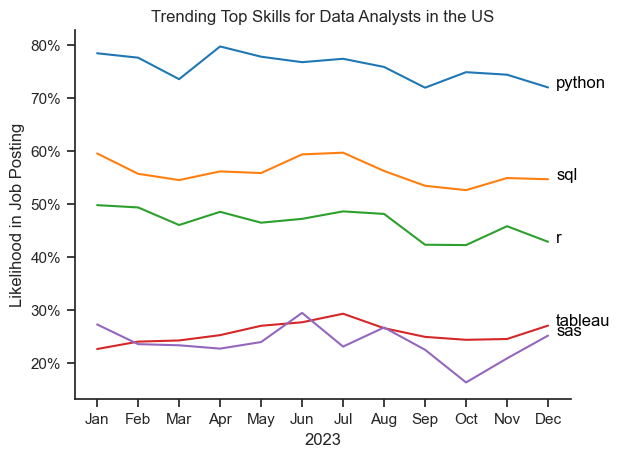

In [95]:
df_plot = df_DA_US_perc.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() # remove top and right spines
plt.legend().remove()

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')
